In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import yfinance as yf
import os
import finnhub
from datetime import datetime, timedelta
import requests
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from torch.nn import TransformerEncoder, TransformerEncoderLayer
import ta 
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands
from ta.trend import MACD
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report,confusion_matrix, roc_curve,mean_squared_error, mean_absolute_error, r2_score
import shap


In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [42]:
ticker = "^IXIC"
start, end = "2010-01-01", "2025-01-01"

In [43]:
df = yf.download(ticker, start=start, end=end, progress=False)
df.columns = df.columns.get_level_values(0)
df["ret"] = df["Close"].pct_change()

C:\Users\naili\AppData\Local\Temp\ipykernel_12852\3750425437.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)


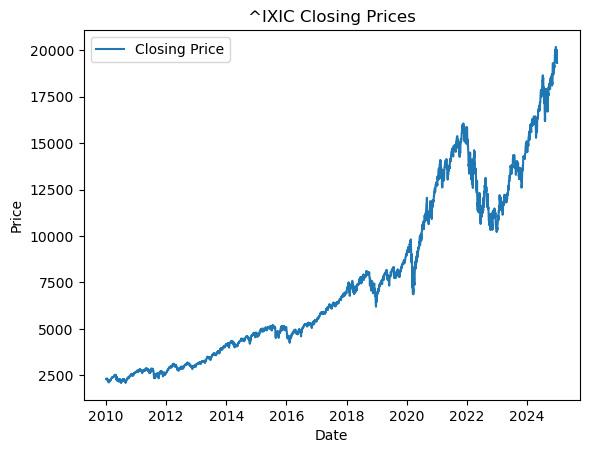

In [45]:
plt.plot(df['Close'], label='Closing Price')
plt.title(f'{ticker} Closing Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [5]:
# =============================================================
#  2. TECHNICAL FEATURES 
# =============================================================

# Shift(1) before rolling to avoid lookahead
for w in [5, 10, 20, 50, 100, 200]:
    df[f'sma_{w}'] = df['Close'].shift(1).rolling(w).mean()
    # use previous close (not today’s) to avoid same-day info
    df[f'close_sma{w}_ratio'] = df['Close'].shift(1) / df[f'sma_{w}'] - 1

# RSI.Aalso use past closes 
df['rsi_14'] = RSIIndicator(df['Close'].shift(1), window=14).rsi()

In [6]:

# =============================================================
#  3. TARGET (5-day forward move)
# =============================================================
fwd5 = df["ret"].shift(-1).rolling(5).sum()
df["target5"] = (fwd5 > 0).astype(int)
df["target1"] = (df["ret"].shift(-1) > 0).astype(int)
df["target5_reg"] = df["ret"].shift(-1).rolling(5).sum()
df['target1_reg'] = df['ret'].shift(-1)
# Clean up
df = df.dropna().reset_index()
df["date"] = df["Date"].dt.date

### FinBert

In [7]:
# =====Load FinBert Model=====
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tok = AutoTokenizer.from_pretrained("ProsusAI/finbert")
mdl = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert").to(device).eval()

In [ ]:
news = pd.read_csv('All_external.csv')

C:\Users\naili\AppData\Local\Temp\ipykernel_15788\3337717661.py:1: DtypeWarning: Columns (2,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  news = pd.read_csv('All_external.csv')


In [8]:
news.shape

(13057514, 11)

In [9]:
news = news[["Date", "Article_title"]].copy()

# Convert Date to datetime and keep only date part
news["Date"] = pd.to_datetime(news["Date"], errors="coerce")
news = news.dropna(subset=["Date"])
news["date"] = news["Date"].dt.date

# Remove duplicates and missing titles
news = news.drop_duplicates(subset=["Article_title"]).dropna(subset=["Article_title"])

print(news.head())

                       Date  \
0 2020-06-05 06:30:54+00:00   
1 2020-06-03 06:45:20+00:00   
2 2020-05-26 00:30:07+00:00   
3 2020-05-22 08:45:06+00:00   
4 2020-05-22 07:38:59+00:00   

                                       Article_title        date  
0            Stocks That Hit 52-Week Highs On Friday  2020-06-05  
1         Stocks That Hit 52-Week Highs On Wednesday  2020-06-03  
2                      71 Biggest Movers From Friday  2020-05-26  
3       46 Stocks Moving In Friday's Mid-Day Session  2020-05-22  
4  B of A Securities Maintains Neutral on Agilent...  2020-05-22  


In [8]:
def finbert_batch_sentiment(texts, batch_size=64, max_length=128):
    results = []
    mdl.eval()  

    for i in tqdm(range(0, len(texts), batch_size), desc="FinBERT Sentiment", ncols=100):
        batch = texts[i:i+batch_size]

        enc = tok(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        ).to(device)

        with torch.inference_mode():  # ensures no gradients = faster 
            probs = torch.softmax(mdl(**enc).logits, dim=-1)

        results.extend(probs.cpu().numpy())

    return pd.DataFrame(results, columns=["pos", "neu", "neg"])


In [ ]:
# --- Run FinBERT on news titles ---
texts = news["Article_title"].astype(str).tolist()
sent_df = finbert_batch_sentiment(texts, batch_size=64)

FinBERT Sentiment: 100%|██████████████████████████████████| 149079/149079 [3:55:03<00:00, 10.57it/s]


In [ ]:
# --- Combine FinBERT sentiment with the news dataframe ---
news_with_sent = pd.concat([news.reset_index(drop=True), sent_df], axis=1)

In [9]:
# --- SAVE RESULTS TO PARQUET to reload without running BERT---
news_with_sent.to_parquet("finbert_sentiment_scores.parquet", index=False)

NameError: name 'news_with_sent' is not defined

In [7]:
# =============================================================
#  4. LOAD SENTIMENT DATA (FinBERT precomputed took about 5 hours to run on 4060RTX for a dataset of 6GB)
# =============================================================
news = pd.read_parquet("finbert_sentiment_scores.parquet")
news["date"] = pd.to_datetime(news["date"]).dt.date

In [8]:
# Aggregate daily sentiment
daily_sent = (
    news.groupby("date")
    .agg({"pos": "mean", "neu": "mean", "neg": "mean", "Article_title": "count"})
    .rename(columns={"Article_title": "article_count"})
    .reset_index()
)

In [9]:
# =============================================================
#  5. MERGE SENTIMENT WITH MARKET DATA
# =============================================================
merged = pd.merge(df, daily_sent, on="date", how="left")

# Shift sentiment by 1 day — only use info known up to t-1
merged[["pos", "neu", "neg", "article_count"]] = (
    merged[["pos", "neu", "neg", "article_count"]].shift(1)
)

In [10]:
# =============================================================
#  6. SENTIMENT NORMALIZATION 
# =============================================================
for col in ["pos","neg"]:
    # shift sentiment before computing z-score (only use past info)
    col_shift = merged[col].shift(1)
    merged[f"{col}_z"] = (
        col_shift
        .expanding(min_periods=60)
        .apply(lambda x: (x.iloc[-1] - x.mean()) / (x.std() + 1e-6), raw=False)
    )

In [11]:
# Article-weighted sentiment
merged["sent_net"] = (merged["pos"] - merged["neg"]) * np.log1p(merged["article_count"])

# Add lags for short-term sentiment memory
for L in [1, 2, 3]:
    merged[f"sent_net_lag{L}"] = merged["sent_net"].shift(L)

In [12]:
# =============================================================
#  7. MARKET MEMORY + SEASONALITY
# =============================================================
for L in [1, 2, 3, 5, 10]:
    merged[f"ret_lag{L}"] = merged["ret"].shift(L)

merged["dow"] = pd.to_datetime(merged["Date"]).dt.weekday
merged["month"] = pd.to_datetime(merged["Date"]).dt.month

merged = merged.dropna().reset_index(drop=True)

In [13]:

# =============================================================
#  8. FEATURE SELECTION
# =============================================================
ratio_cols = [c for c in merged.columns if "close_sma" in c]
vol_cols = [c for c in merged.columns if "realvol" in c]
sent_cols = [
    "pos",
    "neu",
    "neg",
    "article_count",
    "pos_z",
    "neg_z",
    "sent_net",
    "sent_net_lag1",
    "sent_net_lag2",
    "sent_net_lag3",
]
lag_cols = [c for c in merged.columns if c.startswith("ret_lag")]
seasonal_cols = ["dow", "month"]

feature_cols = ratio_cols + vol_cols + sent_cols + lag_cols + seasonal_cols

print(f" Total features selected: {len(feature_cols)}")
print(f'feature_cols: {feature_cols}')


 Total features selected: 23
feature_cols: ['close_sma5_ratio', 'close_sma10_ratio', 'close_sma20_ratio', 'close_sma50_ratio', 'close_sma100_ratio', 'close_sma200_ratio', 'pos', 'neu', 'neg', 'article_count', 'pos_z', 'neg_z', 'sent_net', 'sent_net_lag1', 'sent_net_lag2', 'sent_net_lag3', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag10', 'dow', 'month']


In [25]:
# =============================================================
#  9. BUILD X, y ARRAYS
# =============================================================
X_full = merged[feature_cols].astype(np.float32).values
y_full = merged["target5"].astype(np.float32).values

# =============================================================
#  10. CREATE SEQUENCES (Chronologically Safe)
# =============================================================
def create_sequences_np(X, y, seq_len=10):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

seq_len = 10
X_seq, y_seq = create_sequences_np(X_full, y_full, seq_len)


In [26]:
dates = merged["Date"].values
seq_len = 10
print("\nAlignment check (feature window vs target):")
for idx in range(3):
    print(f"Seq ends at {dates[idx+seq_len-1]} -> target is {dates[idx+seq_len]}")


Alignment check (feature window vs target):
Seq ends at 2011-01-28T00:00:00.000000000 -> target is 2011-01-31T00:00:00.000000000
Seq ends at 2011-01-31T00:00:00.000000000 -> target is 2011-02-01T00:00:00.000000000
Seq ends at 2011-02-01T00:00:00.000000000 -> target is 2011-02-02T00:00:00.000000000


In [27]:
# =============================================================
#  11. TRAIN / VAL / TEST SPLIT (Chronological)
# =============================================================
n = len(X_seq)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train, y_train = X_seq[:train_end], y_seq[:train_end]
X_val, y_val = X_seq[train_end:val_end], y_seq[train_end:val_end]
X_test, y_test = X_seq[val_end:], y_seq[val_end:]

In [28]:
# =============================================================
#  12. SCALING (Fit only on train)
# =============================================================
scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, X_train.shape[2]))

def transform(arr, scaler):
    shp = arr.shape
    arr2 = arr.reshape(-1, shp[2])
    arr2 = scaler.transform(arr2)
    return arr2.reshape(shp)

X_train = transform(X_train, scaler)
X_val = transform(X_val, scaler)
X_test = transform(X_test, scaler)

In [29]:
# =============================================================
#  13. CONVERT TO TENSORS
# =============================================================
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

In [30]:

# =============================================================
#  14. MODEL DEFINITION (Transformer Classifier)
# =============================================================
class TransformerClassifier(nn.Module):
    def __init__(self, feature_dim, d_model=64, n_heads=4,
                 ff_dim=128, num_layers=2, dropout=0.2, max_len=512):
        super().__init__()

        self.input_proj = nn.Linear(feature_dim, d_model)
        self.pos_embedding = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation='relu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.attn_pool = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.Tanh(),
            nn.Linear(d_model, 1)
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        x = self.input_proj(x)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        x = x + self.pos_embedding(positions)
        x = self.dropout(x)
        x = self.encoder(x)
        attn_weights = torch.softmax(self.attn_pool(x), dim=1)
        x = torch.sum(attn_weights * x, dim=1)
        return self.classifier(x)


In [31]:
# =============================================================
#  15. MODEL INITIALIZATION
# =============================================================
model = TransformerClassifier(
    feature_dim=X_train.shape[2],
    d_model=96,
    n_heads=4,
    ff_dim=192,
    num_layers=1,
    dropout=0.1,
    max_len=X_train.shape[1]
).to(device)

In [32]:
# =============================================================
#  16. CLASS WEIGHTING (Handle class imbalance)
# =============================================================
num_pos = float((y_train.numpy() == 1).sum())
num_neg = float((y_train.numpy() == 0).sum())
pos_weight = torch.tensor([num_neg / max(num_pos, 1.0)], dtype=torch.float32).to(device)
print(f"Pos weight (train): {pos_weight.item():.3f}")

# =============================================================
#  17. LOSS, OPTIMIZER, SCHEDULER
# =============================================================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# =============================================================
#  18. TRAINING LOOP WITH EARLY STOPPING
# =============================================================
EPOCHS = 1000
patience = 15
best_val = float('inf')
pat_cnt = 0
best_state = None

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, EPOCHS + 1):
    # ----- TRAIN -----
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device).unsqueeze(1)

        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = (torch.sigmoid(logits) > 0.5).float()
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total

    # ----- VALIDATION -----
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device).unsqueeze(1)
            logits = model(Xb)
            loss = criterion(logits, yb)
            val_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch:03d}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.3f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.3f}")

    # ----- EARLY STOPPING -----
    if avg_val_loss < best_val - 1e-4:
        best_val = avg_val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        pat_cnt = 0
    else:
        pat_cnt += 1
        if pat_cnt >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val:.4f}")
            break

# Restore best weights
if best_state:
    model.load_state_dict(best_state)
    print("✅ Restored best model weights.")

Pos weight (train): 0.680
Epoch [001/1000] Train Loss: 0.5671 | Train Acc: 0.405 | Val Loss: 0.5628 | Val Acc: 0.393
Epoch [002/1000] Train Loss: 0.5649 | Train Acc: 0.405 | Val Loss: 0.5607 | Val Acc: 0.393
Epoch [003/1000] Train Loss: 0.5639 | Train Acc: 0.408 | Val Loss: 0.5592 | Val Acc: 0.393
Epoch [004/1000] Train Loss: 0.5632 | Train Acc: 0.413 | Val Loss: 0.5578 | Val Acc: 0.393
Epoch [005/1000] Train Loss: 0.5613 | Train Acc: 0.418 | Val Loss: 0.5567 | Val Acc: 0.393
Epoch [006/1000] Train Loss: 0.5610 | Train Acc: 0.421 | Val Loss: 0.5558 | Val Acc: 0.393
Epoch [007/1000] Train Loss: 0.5601 | Train Acc: 0.426 | Val Loss: 0.5547 | Val Acc: 0.390
Epoch [008/1000] Train Loss: 0.5600 | Train Acc: 0.440 | Val Loss: 0.5538 | Val Acc: 0.390
Epoch [009/1000] Train Loss: 0.5597 | Train Acc: 0.445 | Val Loss: 0.5531 | Val Acc: 0.390
Epoch [010/1000] Train Loss: 0.5594 | Train Acc: 0.448 | Val Loss: 0.5524 | Val Acc: 0.390
Epoch [011/1000] Train Loss: 0.5595 | Train Acc: 0.458 | Val Los

In [33]:

model.eval()
test_probs, test_true = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        probs = torch.sigmoid(model(Xb.to(device))).cpu().numpy().ravel()
        test_probs.append(probs)
        test_true.append(yb.numpy().ravel())

test_probs = np.concatenate(test_probs)
test_true = np.concatenate(test_true)

# --- Base metrics (threshold = 0.5) ---
test_preds = (test_probs >= 0.5).astype(int)
acc = accuracy_score(test_true, test_preds)
f1 = f1_score(test_true, test_preds)
auc = roc_auc_score(test_true, test_probs)
cm = confusion_matrix(test_true, test_preds)

print("=" * 70)
print("📊 EVALUATION RESULTS (Threshold = 0.5)")
print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:\n", classification_report(test_true, test_preds, digits=3))
print("=" * 70)


📊 EVALUATION RESULTS (Threshold = 0.5)
Accuracy : 0.7175
F1-score : 0.7881
ROC-AUC  : 0.7724
Confusion Matrix:
[[ 68  48]
 [ 52 186]]

Classification Report:
               precision    recall  f1-score   support

         0.0      0.567     0.586     0.576       116
         1.0      0.795     0.782     0.788       238

    accuracy                          0.718       354
   macro avg      0.681     0.684     0.682       354
weighted avg      0.720     0.718     0.719       354



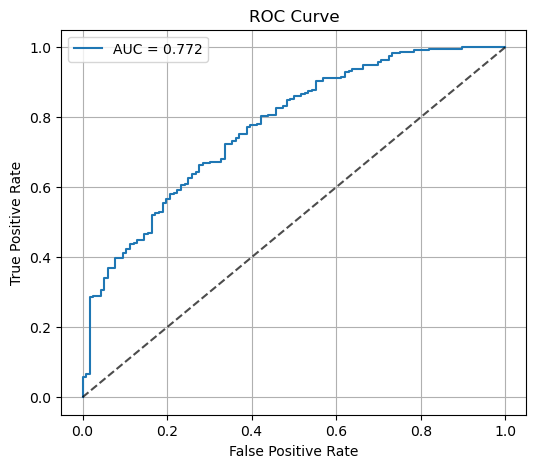

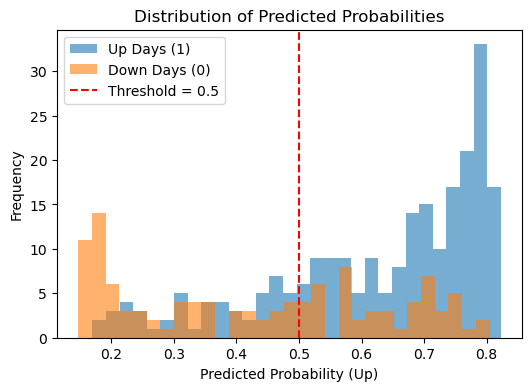

In [34]:
# --- ROC Curve ---
fpr, tpr, _ = roc_curve(test_true, test_probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# --- Distribution of Predicted Probabilities ---
plt.figure(figsize=(6,4))
plt.hist(test_probs[test_true==1], bins=30, alpha=0.6, label="Up Days (1)")
plt.hist(test_probs[test_true==0], bins=30, alpha=0.6, label="Down Days (0)")
plt.axvline(0.5, color="red", linestyle="--", label="Threshold = 0.5")
plt.title("Distribution of Predicted Probabilities")
plt.xlabel("Predicted Probability (Up)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [23]:
# =============================================================
#  REGRESSION VERSION
# =============================================================
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# =============================================================
#  TRAINING LOOP (REGRESSION)
# =============================================================
EPOCHS = 1000
patience = 15
best_val = float('inf')
pat_cnt = 0
best_state = None

train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ----- TRAIN -----
    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device).unsqueeze(1)

        optimizer.zero_grad()
        preds = model(Xb)              # raw regression output
        loss = criterion(preds, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # ----- VALIDATION -----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device).unsqueeze(1)
            preds = model(Xb)
            loss = criterion(preds, yb)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch:03d}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # ----- EARLY STOPPING -----
    if avg_val_loss < best_val - 1e-6:
        best_val = avg_val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        pat_cnt = 0
    else:
        pat_cnt += 1
        if pat_cnt >= patience:
            print(f"Early stopping at epoch {epoch}. Best val loss: {best_val:.6f}")
            break

# Restore best weights
if best_state:
    model.load_state_dict(best_state)
    print("✅ Restored best model weights.")


Epoch [001/1000] Train Loss: 1.745288 | Val Loss: 1.286422
Epoch [002/1000] Train Loss: 1.428237 | Val Loss: 0.997351
Epoch [003/1000] Train Loss: 1.080796 | Val Loss: 0.709995
Epoch [004/1000] Train Loss: 0.718437 | Val Loss: 0.429292
Epoch [005/1000] Train Loss: 0.376483 | Val Loss: 0.192854
Epoch [006/1000] Train Loss: 0.117810 | Val Loss: 0.050650
Epoch [007/1000] Train Loss: 0.019637 | Val Loss: 0.014452
Epoch [008/1000] Train Loss: 0.012797 | Val Loss: 0.010068
Epoch [009/1000] Train Loss: 0.010435 | Val Loss: 0.008066
Epoch [010/1000] Train Loss: 0.009757 | Val Loss: 0.007083
Epoch [011/1000] Train Loss: 0.008852 | Val Loss: 0.006121
Epoch [012/1000] Train Loss: 0.007728 | Val Loss: 0.005412
Epoch [013/1000] Train Loss: 0.007566 | Val Loss: 0.004909
Epoch [014/1000] Train Loss: 0.007336 | Val Loss: 0.004363
Epoch [015/1000] Train Loss: 0.006381 | Val Loss: 0.003747
Epoch [016/1000] Train Loss: 0.005985 | Val Loss: 0.003404
Epoch [017/1000] Train Loss: 0.006196 | Val Loss: 0.0033

In [24]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds = model(Xb.to(device)).cpu().numpy().ravel()
        y_pred.extend(preds)
        y_true.extend(yb.numpy().ravel())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("MSE :", mean_squared_error(y_true, y_pred))
print("MAE :", mean_absolute_error(y_true, y_pred))
print("R²  :", r2_score(y_true, y_pred))

MSE : 0.0018331159371882677
MAE : 0.02929222770035267
R²  : -0.7039221525192261
